## **Libraries**

In [73]:
# Import libraries
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split

## **PD Model**

### **Data**

In [74]:
# Load processed data
loan_data = pd.read_csv(os.path.join("..", "data", "processed", "loan_data_0714.csv"))

C:\Users\luca.saccilotto\AppData\Local\Temp\ipykernel_14992\38153669.py:2: DtypeWarning: Columns (20,48) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data = pd.read_csv(os.path.join("..", "data", "processed", "loan_data_0714.csv"))


In [75]:
# Display unique values of a column
loan_data["loan_status"].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [76]:
# Calculate the number of observations for each unique value of a variable
loan_data["loan_status"].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [77]:
# Get the proportion of observations for each unique value of a variable
loan_data["loan_status"].value_counts() / loan_data["loan_status"].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [78]:
# Create a binary variable to classify the performance of the loan
loan_data["loan_performance"] = np.where(loan_data["loan_status"].isin(["Charged Off", 
                                                                        "Default",
                                                                        "Does not meet the credit policy. Status:Charged Off",
                                                                        "Late (31-120 days)"]), 0, 1)
loan_data["loan_performance"].head()

0    1
1    0
2    1
3    1
4    1
Name: loan_performance, dtype: int32

In [79]:
# Split two data frames with inputs and targets and each into a train and test set
inputs_train, inputs_test, targets_train, targets_test = train_test_split(loan_data.drop("loan_performance", axis = 1), loan_data["loan_performance"], test_size = 0.2, random_state = 42)

print(f"Inputs (Train): {inputs_train.shape}")
print(f"Target (Train): {targets_train.shape}\n")

print(f"Inputs (Test): {inputs_test.shape}")
print(f"Target (Test): {targets_test.shape}")

Inputs (Train): (373028, 207)
Target (Train): (373028,)

Inputs (Test): (93257, 207)
Target (Test): (93257,)


In [80]:
# Define a function to calculate the weight of average for discrete variable
def woe_discrete(df, variable_name, df_good_bad):
    # Concatenate the discrete variable with the input data frame
    df = pd.concat([df[variable_name], df_good_bad], axis = 1)
    # Group by the discrete variable and calculate the number of observations and mean of the variable
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    # Select the columns that indicates the name of variable and the number and mean of observations
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], "n_obs", "prop_good"]
    # Calculate the proportion of observations for each category
    df["prop_obs"] = df["n_obs"] / df["n_obs"].sum()
    # Compute the number of "good" cases and "bad" cases for each category
    df["n_good"] = df["prop_good"] * df["n_obs"]
    df["n_bad"] = (1 - df["prop_good"]) * df["n_obs"]
    # Calculate the proportion of "good" and "bad" cases
    df["prop_good"] = df["n_good"] / df["n_good"].sum()
    df["prop_bad"] = df["n_bad"] / df["n_bad"].sum()
    # Compute the Weight of Evidence (WoE) for each category
    df["WoE"] = np.log(df["prop_good"] / df["prop_bad"])
    # Sort the data frame by WoE
    df = df.sort_values(["WoE"])
    # Reset the index of the data frame
    df = df.reset_index(drop = True)
    # Calculate the absolute difference in "prop_good" and "WoE" between consecutive categories
    df["diff_prop_good"] = df["prop_good"].diff().abs()
    df["diff_WoE"] = df["WoE"].diff().abs()
    # Compute the Information Value (IV) for the entire variable
    df["IV"] = (df["prop_good"] - df["prop_bad"]) * df["WoE"]
    df["IV"] = df["IV"].sum()
    return df

In [81]:
# Define a function that displays results
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    y = df_WoE["WoE"]
    plt.figure(figsize = (12, 3))
    sns.set_style("white")
    plt.plot(x, y, marker = "o", linestyle = "--", color = "k")
    plt.xlabel(df_WoE.columns[0], fontsize = 12)
    plt.ylabel("Weight of Evidence", fontsize = 12)
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [82]:
# Create the necessary arguments
df_inputs = inputs_train
df_targets = targets_train

In [83]:
# Variable: "grade"
df_temp = woe_discrete(df_inputs, "grade", df_targets)
df_temp

,grade,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.005815,0.007115,1932.0,722.0,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.023910,0.028228,7944.0,2586.0,0.063417,-0.975440,0.018095,0.138019,0.288636
2,E,28612,0.069345,0.076702,23040.0,5572.0,0.136642,-0.678267,0.045436,0.297173,0.288636
3,D,61498,0.156647,0.164862,52046.0,9452.0,0.231792,-0.391843,0.087302,0.286424,0.288636
4,C,100245,0.267251,0.268733,88794.0,11451.0,0.280813,-0.049503,0.110603,0.342340,0.288636
5,B,109730,0.304178,0.294160,101063.0,8667.0,0.212541,0.358476,0.036927,0.407979,0.288636
6,A,59759,0.172855,0.160200,57431.0,2328.0,0.057090,1.107830,0.131323,0.749353,0.288636


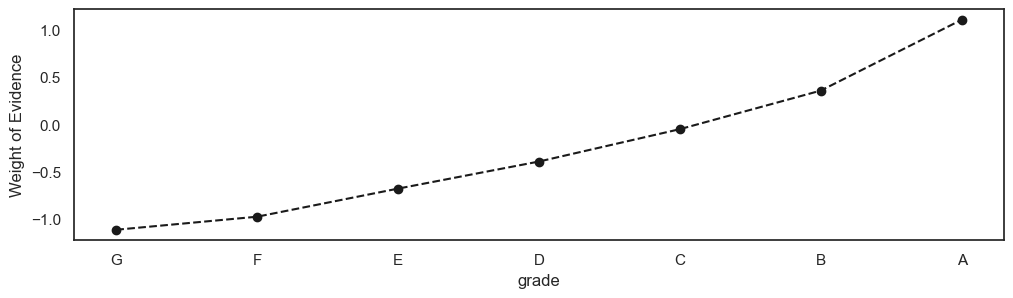

In [84]:
# Plot the weight of evidence values
plot_by_woe(df_temp)

In [85]:
# Variable: "home_ownership"
df_temp = woe_discrete(df_inputs, "home_ownership", df_targets)
df_temp

,home_ownership,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,137,0.000328,0.000367,109.0,28.0,0.000687,-0.738602,NaN,NaN,inf
1,NONE,40,0.000102,0.000107,34.0,6.0,0.000147,-0.363144,0.000226,0.375458,inf
2,RENT,150599,0.396099,0.403720,131604.0,18995.0,0.465815,-0.162123,0.395997,0.201021,inf
3,OWN,33295,0.089442,0.089256,29717.0,3578.0,0.087743,0.019170,0.306658,0.181294,inf
4,MORTGAGE,188956,0.514026,0.506546,170785.0,18171.0,0.445608,0.142834,0.424584,0.123663,inf
5,ANY,1,0.000003,0.000003,1.0,0.0,0.000000,inf,0.514023,inf,inf


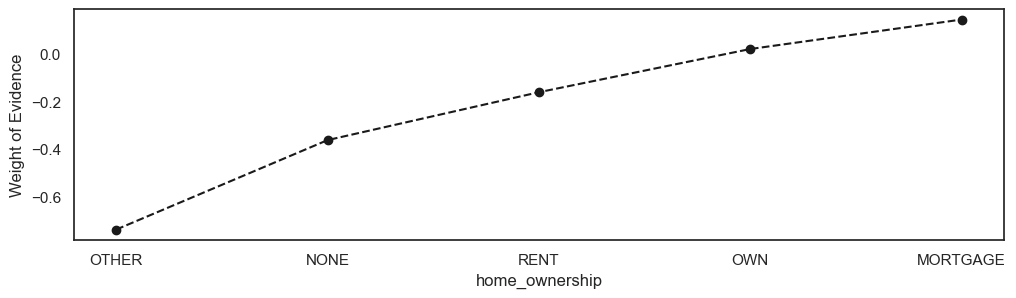

In [86]:
# Plot the weight of evidence values
plot_by_woe(df_temp)

In [87]:
# Create a new discrete variable to combine some of the categories
df_inputs["home_ownership:RENT_OTHER_NONE_ANY"] = sum([df_inputs["home_ownership:RENT"],
                                                       df_inputs["home_ownership:OTHER"],
                                                       df_inputs["home_ownership:NONE"],
                                                       df_inputs["home_ownership:ANY"]])

In [88]:
# Variable: "addr_state"
df_temp = woe_discrete(df_inputs, "addr_state", df_targets)
df_temp.head()

,addr_state,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,13,0.000018,0.000035,6.0,7.0,0.000172,-2.251896,NaN,NaN,inf
1,IA,13,0.000030,0.000035,10.0,3.0,0.000074,-0.893772,0.000012,1.358123,inf
2,NV,5221,0.013586,0.013996,4514.0,707.0,0.017338,-0.243837,0.013556,0.649935,inf
3,FL,25211,0.066456,0.067585,22080.0,3131.0,0.076782,-0.144425,0.052870,0.099411,inf
4,HI,2001,0.005282,0.005364,1755.0,246.0,0.006033,-0.132852,0.061174,0.011573,inf


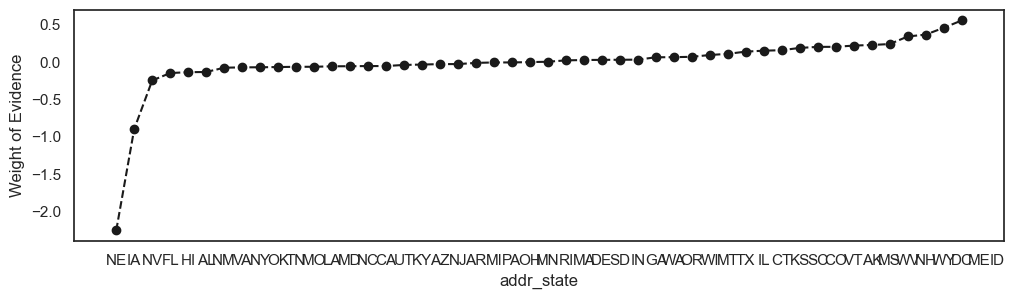

In [89]:
# Plot results
plot_by_woe(df_temp)

In [90]:
# Check if the column exists in the data frame and if it does not add it
if ["addr_state:ND"] in df_inputs.columns.values:
    pass
else:
    df_inputs["addr_state:ND"] = 0

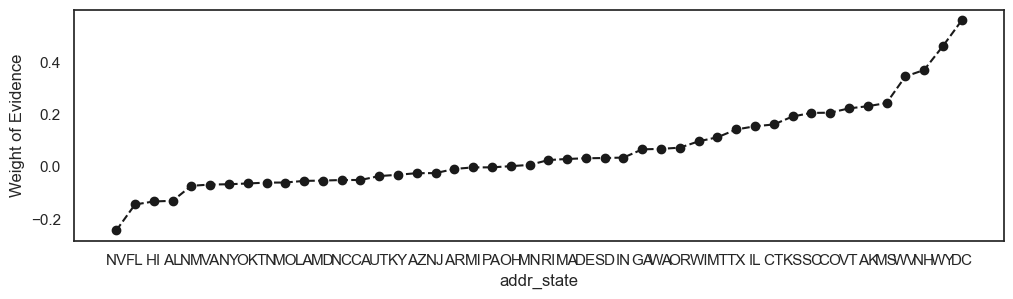

In [91]:
# Plot the weight of evidence values
plot_by_woe(df_temp.iloc[2: -2, : ])

In [92]:
# Create categories using weight of evidence values and set "IA_NV_HI_ID_AL_FL" as the reference one
df_inputs["addr_state:ND_NE_IA_NV_FL_HI_AL"] = sum([df_inputs["addr_state:ND"],
                                                    df_inputs["addr_state:NE"],
                                                    df_inputs["addr_state:IA"],
                                                    df_inputs["addr_state:NV"],
                                                    df_inputs["addr_state:FL"],
                                                    df_inputs["addr_state:HI"],
                                                    df_inputs["addr_state:AL"]])

df_inputs["addr_state:NM_VA"] = sum([df_inputs["addr_state:NM"], df_inputs["addr_state:VA"]])

df_inputs["addr_state:OK_TN_MO_LA_MD_NC"] = sum([df_inputs["addr_state:OK"],
                                                 df_inputs["addr_state:TN"],
                                                 df_inputs["addr_state:MO"],
                                                 df_inputs["addr_state:LA"],
                                                 df_inputs["addr_state:MD"],
                                                 df_inputs["addr_state:NC"]])

df_inputs["addr_state:UT_KY_AZ_NJ"] = sum([df_inputs["addr_state:UT"],
                                           df_inputs["addr_state:KY"],
                                           df_inputs["addr_state:AZ"],
                                           df_inputs["addr_state:NJ"]])

df_inputs["addr_state:AR_MI_PA_OH_MN"] = sum([df_inputs["addr_state:AR"],
                                              df_inputs["addr_state:MI"],
                                              df_inputs["addr_state:PA"],
                                              df_inputs["addr_state:OH"],
                                              df_inputs["addr_state:MN"]])

df_inputs["addr_state:RI_MA_DE_SD_IN"] = sum([df_inputs["addr_state:RI"],
                                              df_inputs["addr_state:MA"],
                                              df_inputs["addr_state:DE"],
                                              df_inputs["addr_state:SD"],
                                              df_inputs["addr_state:IN"]])

df_inputs["addr_state:GA_WA_OR"] = sum([df_inputs["addr_state:GA"],
                                        df_inputs["addr_state:WA"],
                                        df_inputs["addr_state:OR"]])

df_inputs["addr_state:WI_MT"] = sum([df_inputs["addr_state:WI"],
                                     df_inputs["addr_state:MT"]])

df_inputs["addr_state:IL_CT"] = sum([df_inputs["addr_state:IL"],
                                     df_inputs["addr_state:CT"]])

df_inputs["addr_state:KS_SC_CO_VT_AK_MS"] = sum([df_inputs["addr_state:KS"],
                                                 df_inputs["addr_state:SC"],
                                                 df_inputs["addr_state:CO"],
                                                 df_inputs["addr_state:VT"],
                                                 df_inputs["addr_state:AK"],
                                                 df_inputs["addr_state:MS"]])

df_inputs["addr_state:WV_NH_WY_DC_ME_ID"] = sum([df_inputs["addr_state:WV"],
                                                 df_inputs["addr_state:NH"],
                                                 df_inputs["addr_state:WY"],
                                                 df_inputs["addr_state:DC"],
                                                 df_inputs["addr_state:ME"],
                                                 df_inputs["addr_state:ID"]])

In [93]:
# Variable: "verification_status"
df_temp = woe_discrete(df_inputs, "verification_status", df_targets)
df_temp

,verification_status,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134414,0.353090,0.360332,117314.0,17100.0,0.419344,-0.171969,NaN,NaN,0.020384
1,Source Verified,120030,0.323663,0.321772,107537.0,12493.0,0.306366,0.054922,0.029427,0.226891,0.020384
2,Not Verified,118584,0.323248,0.317896,107399.0,11185.0,0.274290,0.164232,0.000415,0.109311,0.020384


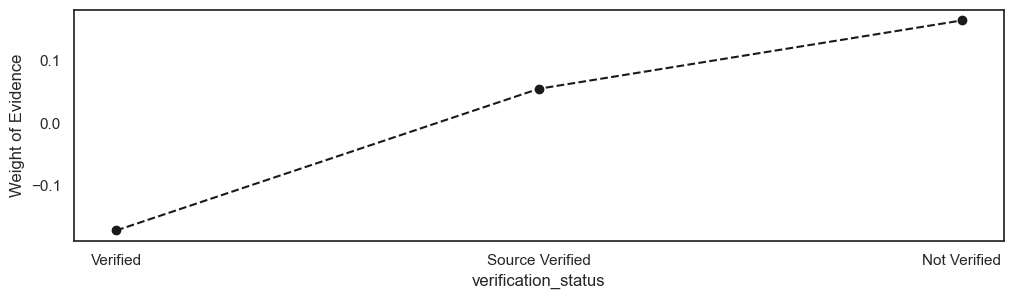

In [94]:
# Plot the weight of evidence values
plot_by_woe(df_temp)

In [95]:
# Variable: "purpose"
df_temp = woe_discrete(df_inputs, "purpose", df_targets)
df_temp

,purpose,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5582,0.013207,0.014964,4388.0,1194.0,0.029280,-0.796180,NaN,NaN,0.035418
1,educational,333,0.000804,0.000893,267.0,66.0,0.001619,-0.700151,0.012403,0.096029,0.035418
2,moving,2392,0.006044,0.006412,2008.0,384.0,0.009417,-0.443493,0.005240,0.256658,0.035418
3,house,1830,0.004737,0.004906,1574.0,256.0,0.006278,-0.281547,0.001306,0.161946,0.035418
4,other,18884,0.049008,0.050624,16283.0,2601.0,0.063784,-0.263519,0.044271,0.018028,0.035418
5,renewable_energy,281,0.000731,0.000753,243.0,38.0,0.000932,-0.242270,0.048277,0.021250,0.035418
6,medical,3684,0.009628,0.009876,3199.0,485.0,0.011894,-0.211300,0.008897,0.030969,0.035418
7,wedding,1887,0.005008,0.005059,1664.0,223.0,0.005469,-0.087937,0.004620,0.123363,0.035418
8,vacation,1991,0.005288,0.005337,1757.0,234.0,0.005738,-0.081703,0.000280,0.006234,0.035418
9,debt_consolidation,219183,0.585071,0.587578,194390.0,24793.0,0.607999,-0.038440,0.579783,0.043263,0.035418


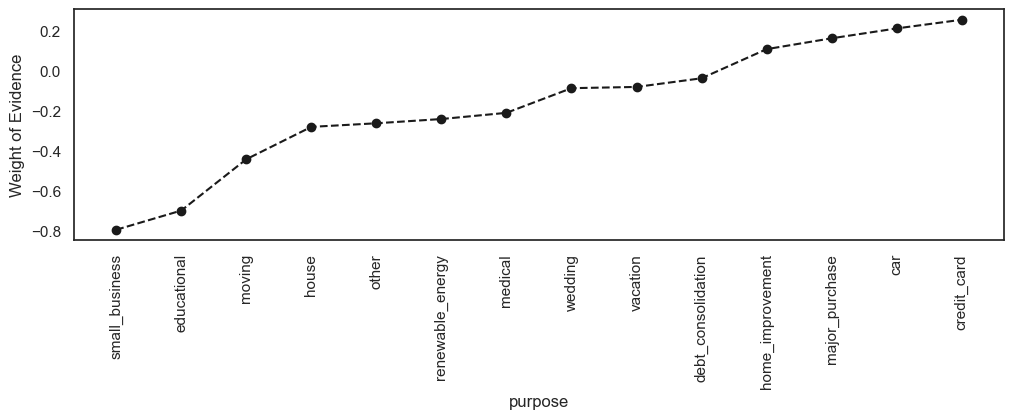

In [96]:
# Plot the weight of evidence values
plot_by_woe(df_temp, 90)

In [97]:
# Create categories using weight of evidence values and set "purpose:e_sb_w_re_m_h" as the reference one
df_inputs["purpose:e_sb_w_re_m_h"] = sum([df_inputs["purpose:educational"],
                                          df_inputs["purpose:small_business"],
                                          df_inputs["purpose:wedding"],
                                          df_inputs["purpose:renewable_energy"],
                                          df_inputs["purpose:moving"],
                                          df_inputs["purpose:house"]])

df_inputs["purpose:o_m_v"] = sum([df_inputs["purpose:other"],
                                  df_inputs["purpose:medical"],
                                  df_inputs["purpose:vacation"]])

df_inputs["purpose:mp_c_hi"] = sum([df_inputs["purpose:major_purchase"],
                                    df_inputs["purpose:car"],
                                    df_inputs["purpose:home_improvement"]])

In [98]:
# Variable: "initial_list_status"
df_temp = woe_discrete(df_inputs, "initial_list_status", df_targets)
df_temp

,initial_list_status,n_obs,prop_good,prop_obs,n_good,n_bad,prop_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242514,0.642101,0.650123,213338.0,29176.0,0.715484,-0.108214,NaN,NaN,0.02478
1,w,130514,0.357899,0.349877,118912.0,11602.0,0.284516,0.229461,0.284202,0.337675,0.02478


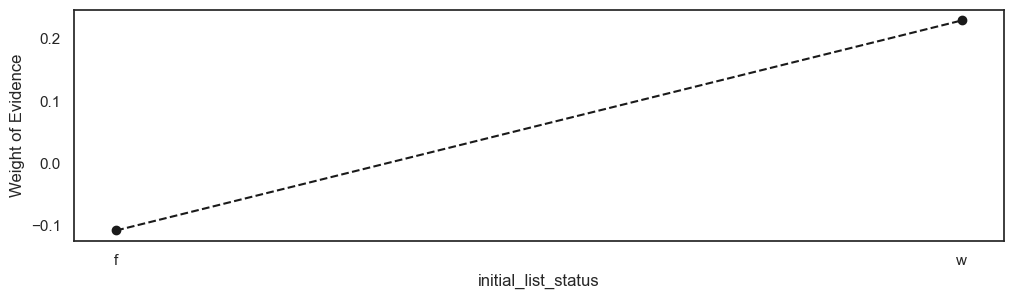

In [99]:
# Plot the weight of evidence values
plot_by_woe(df_temp)

In [100]:
# Define a function for ordered discrete and continuous variables
def woe_ordered_continuous(df, variable_name, df_good_bad):
    # Concatenate the discrete variable with the input data frame
    df = pd.concat([df[variable_name], df_good_bad], axis = 1)
    # Group by the discrete variable and calculate the number of observations and mean of the variable
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    # Select the columns that indicates the name of variable and the number and mean of observations
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], "n_obs", "prop_good"]
    # Calculate the proportion of observations for each category
    df["prop_obs"] = df["n_obs"] / df["n_obs"].sum()
    # Compute the number of "good" cases and "bad" cases for each category
    df["n_good"] = df["prop_good"] * df["n_obs"]
    df["n_bad"] = (1 - df["prop_good"]) * df["n_obs"]
    # Calculate the proportion of "good" and "bad" cases
    df["prop_good"] = df["n_good"] / df["n_good"].sum()
    df["prop_bad"] = df["n_bad"] / df["n_bad"].sum()
    # Compute the Weight of Evidence (WoE) for each category
    df["WoE"] = np.log(df["prop_good"] / df["prop_bad"])
    # Calculate the absolute difference in "prop_good" and "WoE" between consecutive categories
    df["diff_prop_good"] = df["prop_good"].diff().abs()
    df["diff_WoE"] = df["WoE"].diff().abs()
    # Compute the Information Value (IV) for the entire variable
    df["IV"] = (df["prop_good"] - df["prop_bad"]) * df["WoE"]
    df["IV"] = df["IV"].sum()
    return df